# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Evan Sims, David Rha

**ID**: ems452 (5359764) and dgr79 (5433593)

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [72]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("HypothesisTests")

  Activating project at `~/Documents/School/Senior/BEE 4750/hw3-rha-sims-1`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Combinatorics ─── v1.0.3
   Installed HypothesisTests ─ v0.11.5
    Updating `~/Documents/School/Senior/BEE 4750/hw3-rha-sims-1/Project.toml`
  [09f84164] + HypothesisTests v0.11.5
    Updating `~/Documents/School/Senior/BEE 4750/hw3-rha-sims-1/Manifest.toml`
  [7d9f7c33] + Accessors v0.1.42
  [861a8166] + Combinatorics v1.0.3
  [38540f10] + CommonSolve v0.2.4
  [a33af91c] + CompositionsBase v0.1.2
  [187b0558] + ConstructionBase v1.6.0
  [09f84164] + HypothesisTests v0.11.5
  [3587e190] + InverseFunctions v0.1.17
  [f2b01f46] + Roots v2.2.10
Precompiling project...
   1487.6 ms  ✓ Combinatorics
   1055.4 ms  ✓ StatsFuns → StatsFunsInverseFunctionsExt
   2349.4 ms  ✓ HypothesisTests
  3 dependencies successfully precompiled in 5 seconds. 227 already precompiled.


In [73]:
using Random
using Plots
using LaTeXStrings
using Distributions
using HypothesisTests

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

1.1 Minimum DO = 3.572 mg/L at x = 23.25 km


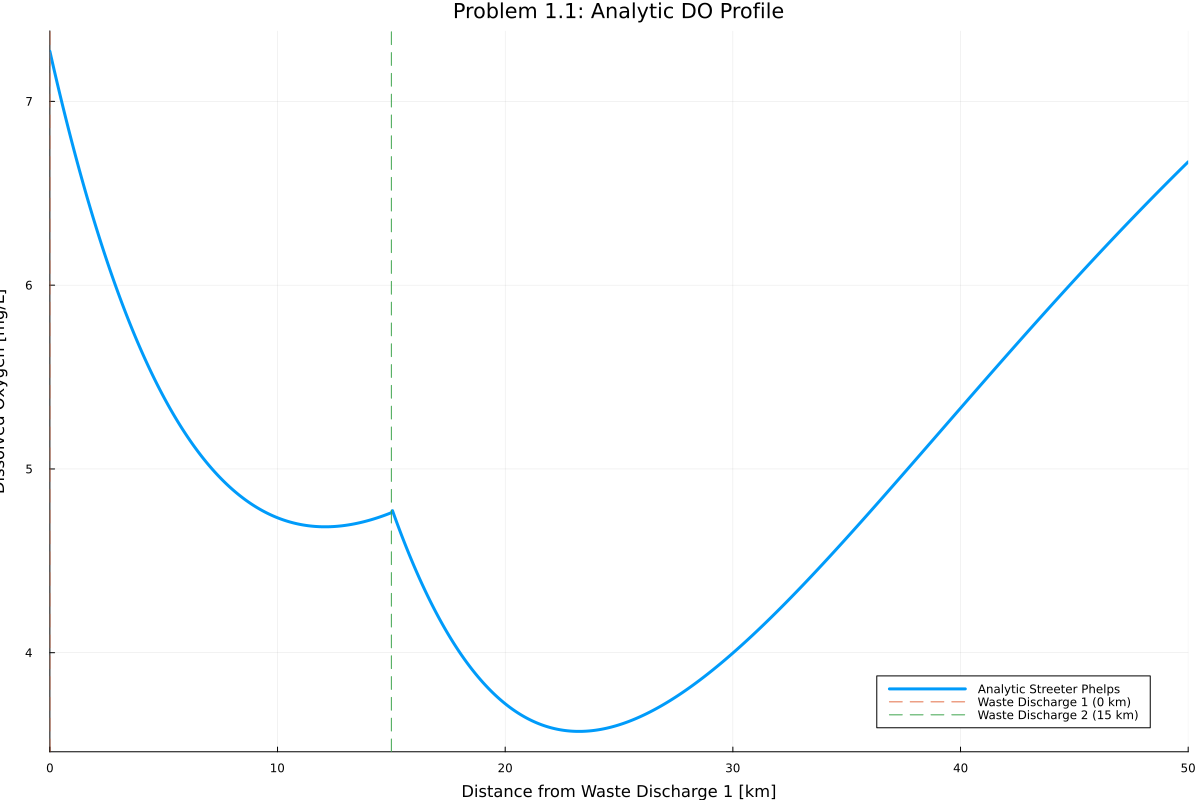

In [74]:
# Flows [m^3/d]
Q_river_inflow   = 100000.0
Q_waste_stream_1 = 10000.0
Q_waste_stream_2 = 15000.0

# Concentrations [mg/L]
DO_river_inflow   = 7.5
DO_waste_stream_1 = 5.0
DO_waste_stream_2 = 5.0

CBOD_river_inflow   = 5.0
CBOD_waste_stream_1 = 50.0
CBOD_waste_stream_2 = 45.0

NBOD_river_inflow   = 5.0
NBOD_waste_stream_1 = 35.0
NBOD_waste_stream_2 = 35.0

# River & Kinetic Properties
U  = 6.0      # km/d
ka = 0.5      # d^-1 (reaeration)
kc = 0.3      # d^-1 (CBOD decay)
kn = 0.25     # d^-1 (NBOD decay)
Cs = 10.0     # mg/L (DO saturation)
dx2 = 15.0    # km between discharges

# Initial mixing with Waste 1 at x = 0 km
Q_segment_1 = Q_river_inflow + Q_waste_stream_1
C0_1 = (Q_river_inflow*DO_river_inflow + Q_waste_stream_1*DO_waste_stream_1) / Q_segment_1
B0_1 = (Q_river_inflow*CBOD_river_inflow + Q_waste_stream_1*CBOD_waste_stream_1) / Q_segment_1
N0_1 = (Q_river_inflow*NBOD_river_inflow + Q_waste_stream_1*NBOD_waste_stream_1) / Q_segment_1

# Analytic C(x) for a single segment that starts at x=0 with (C0,B0,N0)
function DO_analytic(x, C0, B0, N0, ka, kc, kn, Cs, U)
    alpha1 = exp(-ka * x / U)
    alpha2 = (kc/(ka - kc)) * (exp(-kc * x / U) - exp(-ka * x / U))
    alpha3 = (kn/(ka - kn)) * (exp(-kn * x / U) - exp(-ka * x / U))
    C = Cs*(1 - alpha1) + C0*alpha1 - B0*alpha2 - N0*alpha3
    return C
end

# Propagate segment 1 to x = 15 km (just upstream of discharge 2)
C_upstream_2 = DO_analytic(dx2, C0_1, B0_1, N0_1, ka, kc, kn, Cs, U)
B_upstream_2 = B0_1 * exp(-kc * dx2 / U)
N_upstream_2 = N0_1 * exp(-kn * dx2 / U)

# Mix with Waste 2 at x = 15 km (start of segment 2)
Q_segment_2 = Q_segment_1 + Q_waste_stream_2
C0_2 = (Q_segment_1*C_upstream_2 + Q_waste_stream_2*DO_waste_stream_2) / Q_segment_2
B0_2 = (Q_segment_1*B_upstream_2 + Q_waste_stream_2*CBOD_waste_stream_2) / Q_segment_2
N0_2 = (Q_segment_1*N_upstream_2 + Q_waste_stream_2*NBOD_waste_stream_2) / Q_segment_2

# Build C(x) from 0 to 50 km
x_initial = 0.0
x_final   = 50.0
points    = 1001
dx        = (x_final - x_initial) / (points - 1)

x_data = zeros(points)
C_data = zeros(points)

for i in 1:points
    x = x_initial + (i - 1) * dx   # <-- forward, not minus
    x_data[i] = x

    if x <= dx2
        # Segment 1: 0 ≤ x ≤ 15
        C_data[i] = DO_analytic(x, C0_1, B0_1, N0_1, ka, kc, kn, Cs, U)
    else
        # Segment 2: x > 15 (reset origin at 15)
        x_local = x - dx2
        C_data[i] = DO_analytic(x_local, C0_2, B0_2, N0_2, ka, kc, kn, Cs, U)
    end
end

# Find the minimum DO and where it occurs
minimum_C_1 = C_data[1]
initial_min = 1
for i in 2:points
    if C_data[i] < minimum_C_1
        minimum_C_1 = C_data[i]
        initial_min = i
    end
end
minimum_x_1 = x_data[initial_min]

println("1.1 Minimum DO = ", round(minimum_C_1, digits=4), " mg/L at x = ", round(minimum_x_1, digits=2), " km")

# --- Plot
p1 = plot(x_data, C_data;
         linewidth=3, label="Analytic Streeter Phelps",
         xlabel="Distance from Waste Discharge 1 [km]",
         ylabel="Dissolved Oxygen [mg/L]",
         title="Problem 1.1: Analytic DO Profile")

vline!([0.0];  linestyle=:dash, label="Waste Discharge 1 (0 km)")
vline!([dx2];  linestyle=:dash, label="Waste Discharge 2 (15 km)")
plot!(size=(1200, 800))
xaxis!((0, 50))
display(p1)

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Minimum DO = 3.5109 mg/L at x = 23.5 km


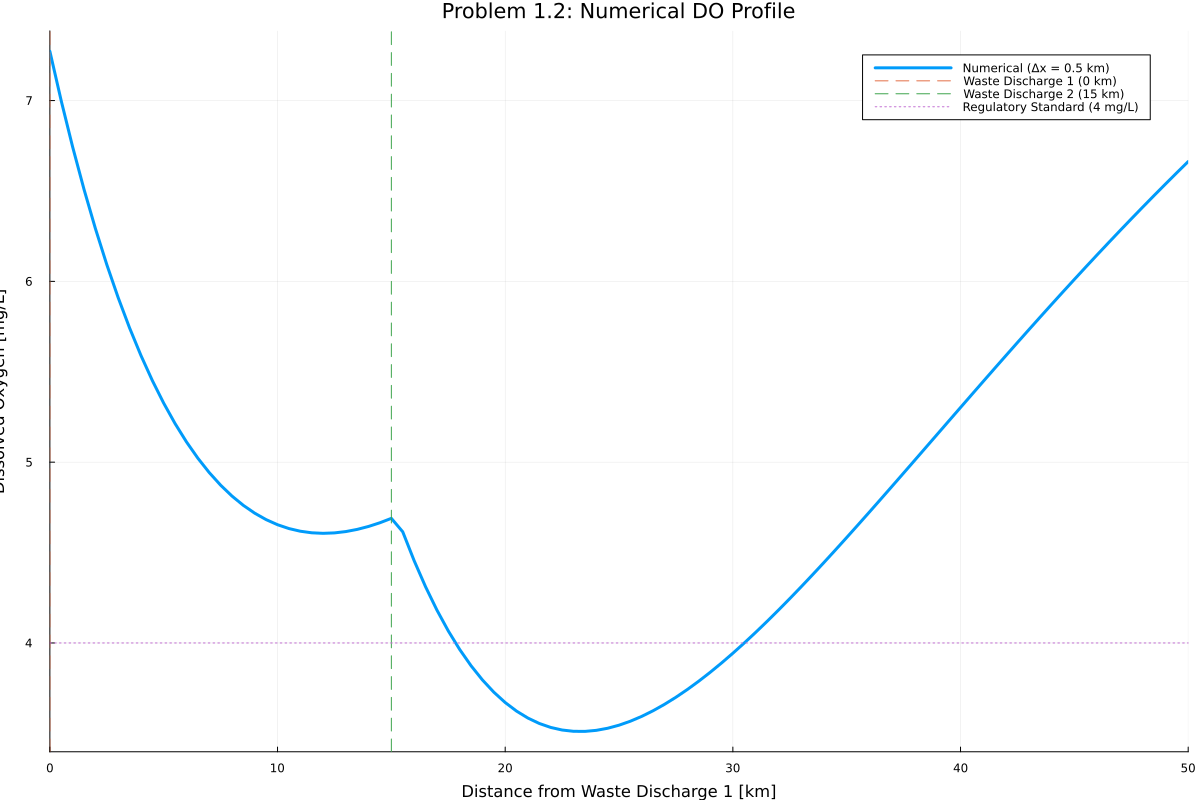

In [76]:
function do_numerical(L, resolution, C0, B0, N0, ka, kn, kc, Cs, U)
    n = Int(L / resolution) # number of length steps
    C = zeros(n + 1)
    B = zeros(n + 1)
    N = zeros(n + 1)
    C[1] = C0
    B[1] = B0
    N[1] = N0
    for i = 1:n
        B[i+1] = B[i] * exp(-kc * resolution / U)
        N[i+1] = N[i] * exp(-kn * resolution / U)
        C[i+1] = C[i] + (resolution / U) * (ka * (Cs - C[i]) - kc * B[i] - kn * N[i])
    end
    return (C, B, N)
end

# Settings
resolution = 0.5 # km (delta X)
length_1 = dx2 # distance from 0 to 15 km
length_2 = 50.0 - dx2 # distance from 15 to 50 km

n1 = Int(length_1 / resolution)
n2 = Int(length_2 / resolution)
total_points = n1 + n2 + 1

# Initialize an array and fill in

x_num = zeros(total_points)
C_num = zeros(total_points)


import Base: convert
convert(::Type{Float64}, t::Tuple{Vector{Float64},Vector{Float64},Vector{Float64}}) = t[1][end]

# Segment 1 Integration
C1, B1, N1 = do_numerical(length_1, resolution, C0_1, B0_1, N0_1, ka, kn, kc, Cs, U)

# Values just before 15 km
C1_end = C1[end]
B1_end = B1[end]
N1_end = N1[end]

# Mix with Waste 2 at x = 15 km (start of segment 2)
Q_segment_2 = Q_segment_1 + Q_waste_stream_2
C0_2 = (Q_segment_1*C_upstream_2 + Q_waste_stream_2*DO_waste_stream_2) / Q_segment_2
B0_2 = (Q_segment_1*B_upstream_2 + Q_waste_stream_2*CBOD_waste_stream_2) / Q_segment_2
N0_2 = (Q_segment_1*N_upstream_2 + Q_waste_stream_2*NBOD_waste_stream_2) / Q_segment_2

# Segment 2 Integration 
C2, B2, N2 = do_numerical(length_2, resolution, C0_2, B0_2, N0_2, ka, kn, kc, Cs, U)

# Initialize an array and fill in
x_num = zeros(total_points)
C_num = zeros(total_points)

# Segment 1 points: indices 1 to n1+1
for i in 1:(n1+1)
    x_num[i] = (i - 1) * resolution
    C_num[i] = C1[i]
end

# Segment 2 points: indices n1+2 to total_points
for i in 1:n2
    index = n1 + 1 + i
    x_num[index] = dx2 + i * resolution
    C_num[index] = C2[i + 1]   # start from C2[2] to avoid duplicating x=15 km
end

# Minimum DO
minC, index_min = findmin(C_num)
x_min = x_num[index_min]
println("Minimum DO = ", round(minC, digits=4), " mg/L at x = ", round(x_min, digits=2), " km")

# === Plot ===
p2 = plot(x_num, C_num; lw=3, label="Numerical (Δx = $(resolution) km)",
          xlabel="Distance from Waste Discharge 1 [km]",
          ylabel="Dissolved Oxygen [mg/L]",
          title="Problem 1.2: Numerical DO Profile")
vline!([0.0];  linestyle=:dash, label="Waste Discharge 1 (0 km)")
vline!([dx2];  linestyle=:dash, label="Waste Discharge 2 (15 km)")
hline!([4.0];  linestyle=:dot, label="Regulatory Standard (4 mg/L)")
xaxis!((0, 50))
plot!(size=(1200, 800))
display(p2)



### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

In [6]:
B = B0 * exp(-kc * x / U)
N = N0 * exp(-kn * x / U)

UndefVarError: UndefVarError: `B0` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

#### P1.4 Answer:
This decision will likely come down to the cost/feasibility of treating the waste from each of the streams. While it may make sense from a fairness perspective to treat both equally, it may be more cost-optimal to focus treatment on one stream if it's much cheaper to do so. As such, understanding information about the cost of treatment for each stream will be important to this decision. 

If both streams are equally costly to treat, we would likely choose to also treat both waste streams equally because stream 2 is unlikely to suppress oxygen concentrations below the mandate if it weren't for the DO impact caused by stream 1. Therefore, it could be more fair to treat both streams equally in this theoretical situation. 

If one waste stream existed first, this could also add another factor to complicate the process. Overall, this is one of those tough decisions with all sorts of factors that could impact the "right" treatment plan and alter your idea of what is considered "right."

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

probability of violating standards = 0.7899
upper 95% interval = 0.7978846365877478
lower 95% interval = 0.7819153634122523


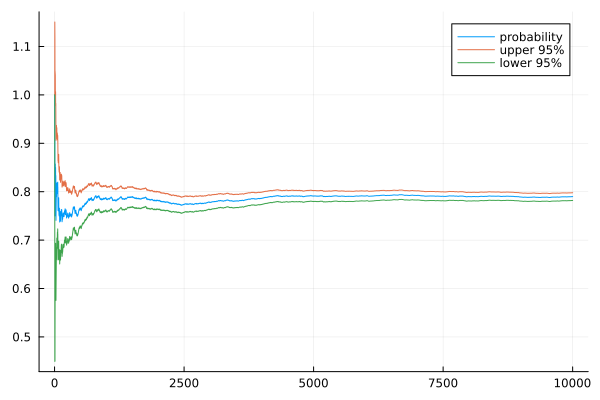

In [ ]:
Random.seed!(1)

#Pull all calcs from part 1.1 into a single function that returns a binary randome variable (1=violation, 0=compliance)  
#this function will take a stream 1 DO level as an input
function do_calc(DO_in)
    # --- Same calcs from 1.1, just using the new inflow_conc for stream 1
    # Flows [m^3/d]
    Q_river_inflow   = 100000.0
    Q_waste_stream_1 = 10000.0
    Q_waste_stream_2 = 15000.0

    # Concentrations [mg/L]
    DO_river_inflow   = DO_in
    DO_waste_stream_1 = 5.0
    DO_waste_stream_2 = 5.0

    CBOD_river_inflow   = 5.0
    CBOD_waste_stream_1 = 50.0 * 0.8 #CHANGE TO THE CORRECT TREATMENT AMOUNT
    CBOD_waste_stream_2 = 45.0

    NBOD_river_inflow   = 5.0
    NBOD_waste_stream_1 = 35.0 * 0.8 #CHANGE TO THE CORRECT TREATMENT AMOUNT
    NBOD_waste_stream_2 = 35.0

    # River & Kinetic Properties
    U  = 6.0      # km/d
    ka = 0.5      # d^-1 (reaeration)
    kc = 0.3      # d^-1 (CBOD decay)
    kn = 0.25     # d^-1 (NBOD decay)
    Cs = 10.0     # mg/L (DO saturation)
    dx2 = 15.0    # km between discharges

    # --- Initial mixing with Waste 1 at x = 0 km
    Q_segment_1 = Q_river_inflow + Q_waste_stream_1
    C0_1 = (Q_river_inflow*DO_river_inflow + Q_waste_stream_1*DO_waste_stream_1) / Q_segment_1
    B0_1 = (Q_river_inflow*CBOD_river_inflow + Q_waste_stream_1*CBOD_waste_stream_1) / Q_segment_1
    N0_1 = (Q_river_inflow*NBOD_river_inflow + Q_waste_stream_1*NBOD_waste_stream_1) / Q_segment_1

    # --- Analytic C(x) for a single segment that starts at x=0 with (C0,B0,N0)
    function DO_analytic(x, C0, B0, N0, ka, kc, kn, Cs, U)
        alpha1 = exp(-ka * x / U)
        alpha2 = (kc/(ka - kc)) * (exp(-kc * x / U) - exp(-ka * x / U))
        alpha3 = (kn/(ka - kn)) * (exp(-kn * x / U) - exp(-ka * x / U))
        C = Cs*(1 - alpha1) + C0*alpha1 - B0*alpha2 - N0*alpha3
        return C
    end

    # --- Propagate segment 1 to x = 15 km (just upstream of discharge 2)
    C_upstream_2 = DO_analytic(dx2, C0_1, B0_1, N0_1, ka, kc, kn, Cs, U)
    B_upstream_2 = B0_1 * exp(-kc * dx2 / U)
    N_upstream_2 = N0_1 * exp(-kn * dx2 / U)

    # --- Mix with Waste 2 at x = 15 km (start of segment 2)
    Q_segment_2 = Q_segment_1 + Q_waste_stream_2
    C0_2 = (Q_segment_1*C_upstream_2 + Q_waste_stream_2*DO_waste_stream_2) / Q_segment_2
    B0_2 = (Q_segment_1*B_upstream_2 + Q_waste_stream_2*CBOD_waste_stream_2) / Q_segment_2
    N0_2 = (Q_segment_1*N_upstream_2 + Q_waste_stream_2*NBOD_waste_stream_2) / Q_segment_2

    # --- Build C(x) from 0 to 50 km
    x_initial = 0.0
    x_final   = 50.0
    points    = 1001
    dx        = (x_final - x_initial) / (points - 1)

    x_data = zeros(points)
    C_data = zeros(points)

    for i in 1:points
        x = x_initial + (i - 1) * dx   # <-- forward, not minus
        x_data[i] = x

        if x <= dx2
            # Segment 1: 0 ≤ x ≤ 15
            C_data[i] = DO_analytic(x, C0_1, B0_1, N0_1, ka, kc, kn, Cs, U)
        else
            # Segment 2: x > 15 (reset origin at 15)
            x_local = x - dx2
            C_data[i] = DO_analytic(x_local, C0_2, B0_2, N0_2, ka, kc, kn, Cs, U)
        end
    end

    # --- Find the minimum DO and where it occurs
    minimum_C_1 = C_data[1]
    initial_min = 1
    for i in 2:points
        if C_data[i] < minimum_C_1
            minimum_C_1 = C_data[i]
            initial_min = i   # <-- update to the current index
        end
    end
    minimum_x_1 = x_data[initial_min]

    if round(minimum_C_1, digits=4) < 4.0 
        return 1 # return 1 to signify violation of the standard      
    else 
        return 0 # return 0 to signify compliance with the standard 
    end
end


# --- Start of new calcs to set up Monte Carlo and find probability and 95% confidence interval
n = 10000 # number of Monte Carlo trials
trials = []
compliance = zeros(n)
prob_chart = []
upper_95 = []
lower_95 = []

#create lognormal distribution
inflow_dist = LogNormal(2.0, 0.15) # create a lognormal distribution for inflow concentrations
inflow_conc = rand(inflow_dist, n) # randomly sample the distribution to get inflow concentrations

#treatment amount
treat = 0.9

#run a for loop to calculate the compliance for each input DO level and plot the current probability and 95% interval
for each in 1:n
    compliance[each] = do_calc(inflow_conc[each])
    prob = sum(compliance)/each
    append!(trials, each)
    append!(prob_chart, prob)
    append!(upper_95, prob + 1.96 * sqrt(prob*(1-prob)/each))
    append!(lower_95, prob - 1.96 * sqrt(prob*(1-prob)/each))
end

prob_violation = sum(compliance)/n

upper_confi = prob_violation + 1.96 * sqrt(prob_violation*(1-prob_violation)/n)
lower_confi = prob_violation - 1.96 * sqrt(prob_violation*(1-prob_violation)/n)

print("probability of violating standards = ", prob_violation, "\n")
print("upper 95% interval = ", upper_confi, "\n")
print("lower 95% interval = ", lower_confi, "\n")

plot(trials, prob_chart, label = "probability" )
plot!(trials, upper_95, label = "upper 95%")
plot!(trials, lower_95, label = "lower 95%")


To see if our Monte Carlo simulation was sufficiently large, we plotted the probability and the 95% confidence intervals after each trial. This allowed us to see when the probability would begin to stabilize sufficiently to feel confident in the value. It appears to stabilize around 5000 trials, so if we were computationally limited, we could halve our number of trials from 10000 to 5000. 

## References

List any external references consulted, including classmates.

https://juliastats.org/HypothesisTests.jl/v0.9/methods/


Used this resource to help me figure out how to calculate a 95% confidence interval for this data: https://sigmazone.com/binomial-confidence-intervals/
